In [12]:
import pandas as pd
import os
import sys
from pathlib import Path

# =========================
# 1. Dateien laden
# =========================

project_root = Path.cwd()
if project_root.name == "Auswertung":
    project_root = project_root.parent

data_dir = project_root / "Daten" / "Daten final"
file_paths = sorted(data_dir.glob("PEI5mgmL_*.TXT"))

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"Datenordner: {data_dir}")
print(f"Dateien: {len(file_paths)}")

print([path.name for path in file_paths])


Python: 3.13.5
pandas: 2.2.3
Datenordner: C:\Users\Max\Documents\bachelor thesis\code\Daten\Daten final
Dateien: 0
[]


In [13]:
from pathlib import Path
import pandas as pd

data_dir = Path(r"C:\Users\Max\Documents\bachelor thesis\data\Daten final")

file_paths = list(data_dir.glob("*.TXT")) + list(data_dir.glob("*.txt"))

if not data_dir.exists():
    raise FileNotFoundError(f"Ordner nicht gefunden: {data_dir}")

if not file_paths:
    raise FileNotFoundError(f"Keine .TXT-Dateien gefunden in: {data_dir}")

columns = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi"
]

dfs = []

for path in file_paths:

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=4,
        names=columns,
        encoding="latin1",
        engine="python"
    )

    filename = path.stem
    parts = filename.split("_")

    if len(parts) >= 3:
        material = parts[0]
        temperature = parts[1]
        mode = parts[2]
    else:
        material = filename
        temperature = None
        mode = None

    first_freq = df["Freq_Hz"].iloc[0]
    df["Spectrum_ID"] = (df["Freq_Hz"] == first_freq).cumsum() - 1

    df["Material"] = material
    df["Temperature"] = temperature
    df["Mode"] = mode
    df["Source_File"] = path.name

    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

groups = df_all.groupby(
    ["Material", "Temperature", "Mode", "Spectrum_ID"],
    dropna=False
)

print(df_all)

         Freq_Hz  Time_s  Eps_real  Eps_imag  Temp_K  MTime_s  Phi_deg  \
0         100.00     0.0    6.2162   0.17024  323.15     7.78  -88.431   
1         150.00     0.0    6.1832   0.16396  323.15    10.32  -88.481   
2         225.00     0.0    6.1510   0.16553  323.15    13.14  -88.458   
3         337.50     0.0    6.1199   0.17290  323.15    16.17  -88.382   
4         506.25     0.0    6.0886   0.18860  323.15    18.70  -88.226   
...          ...     ...       ...       ...     ...      ...      ...   
76485   65684.00  9911.7    5.2356   1.03170  363.15  9966.50  -78.852   
76486   98526.00  9911.7    4.8698   1.14890  363.15  9969.20  -76.725   
76487  147790.00  9911.7    4.4598   1.16180  363.15  9974.20  -75.399   
76488  221680.00  9911.7    4.0975   1.06690  363.15  9976.90  -75.406   
76489  332530.00  9911.7    3.7924   0.88917  363.15  9979.30  -76.805   

        Z_real_Ohm  Z_imag_Ohm   TanPhi  Spectrum_ID  Material Temperature  \
0      105710000.0   2895000.0 -3

Frequenzverlauf

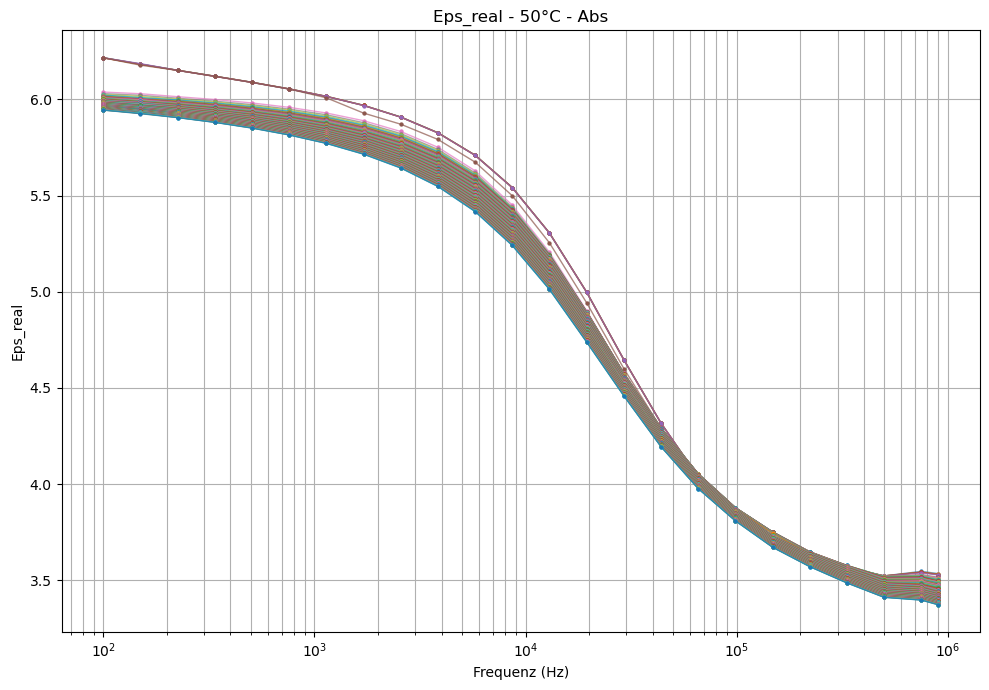

In [20]:
import matplotlib.pyplot as plt

# =========================
# Auswahl
# =========================

temp = "50°C"
mode = "Abs"
y_col = "Eps_real"

df_sel = df_all[
    (df_all["Temperature"] == temp) &
    (df_all["Mode"] == mode)
].copy()

if df_sel.empty:
    raise ValueError(f"Keine Daten gefunden für Temperature={temp} und Mode={mode}")

# =========================
# Sichere Gruppierung
# =========================

group_cols = []

for col in ["Source_File", "Material", "Temperature", "Mode", "Spectrum_ID"]:
    if col in df_sel.columns:
        group_cols.append(col)

# =========================
# Plot
# =========================

plt.figure(figsize=(10, 7))

for keys, spec in df_sel.groupby(group_cols, dropna=False):
    spec = spec.sort_values("Freq_Hz")

    plt.plot(
        spec["Freq_Hz"],
        spec[y_col],
        marker="o",
        markersize=2,
        linewidth=1,
        alpha=0.7
    )

plt.xscale("log")
plt.xlabel("Frequenz (Hz)")
plt.ylabel(y_col)
plt.title(f"{y_col} - {temp} - {mode}")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

Zeitverlauf

Absorption

$\epsilon'$

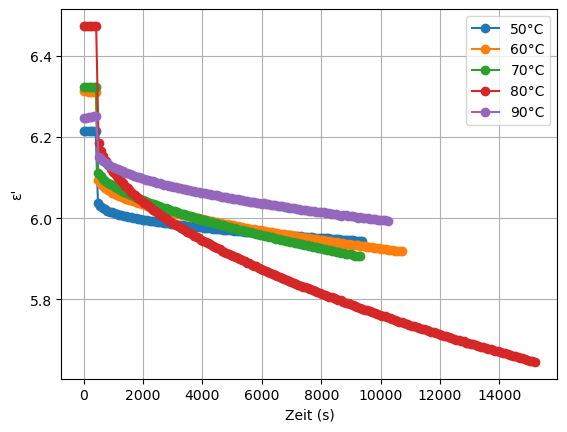

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Abs"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_real"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_real"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon''$

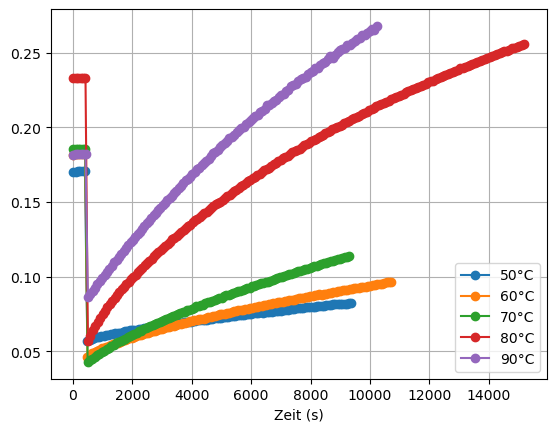

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Abs"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_imag"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_imag"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
#plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon'$

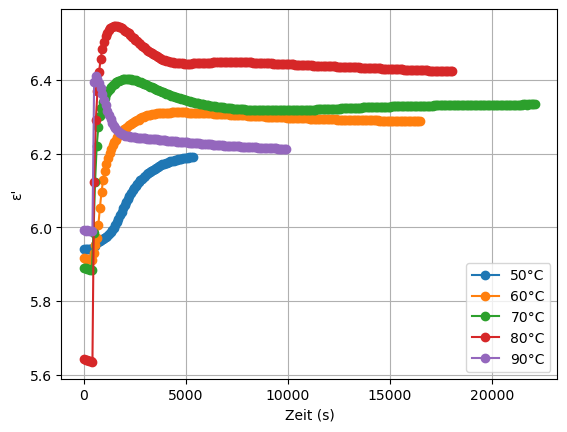

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Des"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_real"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_real"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon''$

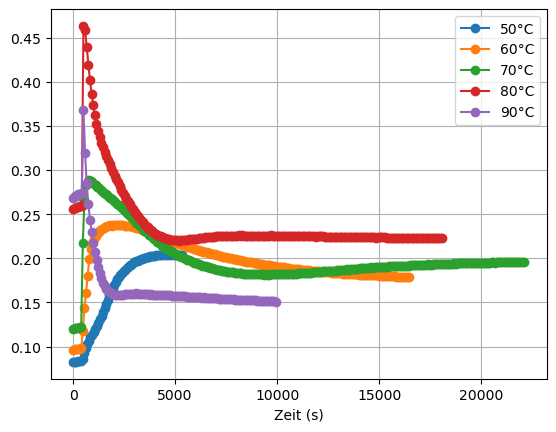

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Des"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_imag"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_imag"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
#plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

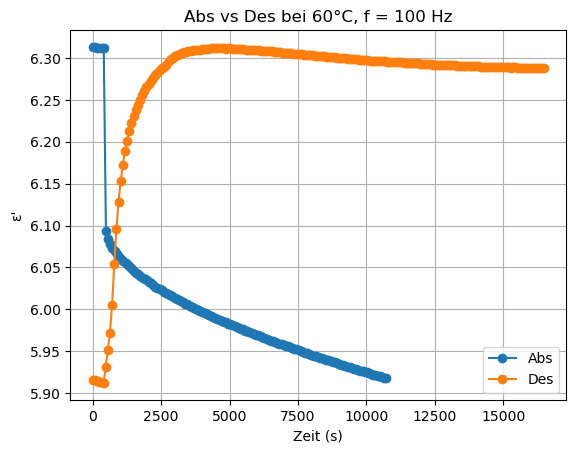

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Parameter
# =========================

f0 = 100
temp = "60°C"

modes = ["Abs", "Des"]

plt.figure()

# =========================
# Loop über Abs / Des
# =========================

for mode in modes:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_real"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_real"],
        marker="o",
        label=mode
    )

# =========================
# Plot Styling
# =========================

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.title(f"Abs vs Des bei {temp}, f = {f0} Hz")
plt.grid(True)
plt.legend()

plt.show()